# Strategy Comparison Backtest

Compares HMM-GMV, HMM-MVO, MSVAR-GMV, MSVAR-MVO, Unconditional-GMV, and Unconditional-MVO against three naive benchmarks over the 2018–2025 test period:
- 60/40 equity-bond portfolio
- Equal-weight equity-bond-gold portfolio
- Buy-and-hold equity portfolio

Requires pre-computed target weight CSVs from notebooks 03 and 04.


## Cost treatment

Transaction costs: 10 bps applied to traded notional (sum of absolute weight changes after drift adjustment).  A 1-month signal lag is applied for all model strategies to prevent look-ahead bias.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os

sys.path.insert(0, os.path.abspath('..'))

from src.constants import ASSET_COLS
from src.data_loader import load_asset_data, load_target_weights, validate_target_weights
from src.benchmarks import (build_constant_weights, build_equal_weight_benchmark,
                              build_sixty_forty_benchmark, build_equity_only_benchmark)
from src.backtest import backtest_with_transaction_costs, apply_asset_level_tax_sensitivity
from src.metrics import summarize_performance
from src.portfolio import build_unconditional_portfolio

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR         = Path('..')
DATA_DIR         = BASE_DIR / 'data'
OUTPUT_TABLES_DIR  = BASE_DIR / 'outputs' / 'tables'
OUTPUT_FIGURES_DIR = BASE_DIR / 'outputs' / 'figures'
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Signal start dates ────────────────────────────────────────────────────────
# HMM  : no lag consumption — labels align to dates_train
# MSVAR: VAR(p=1) consumes 1 lag — labels align to dates_train[1:]
# Both strategies apply a 1-month forward signal lag in the backtest engine.
MODEL_SIGNAL_START_DATES = {
    "HMM_GMV":   pd.Timestamp("2018-10-31"),
    "HMM_MVO":   pd.Timestamp("2018-10-31"),
    "MSVAR_GMV": pd.Timestamp("2018-11-30"),
    "MSVAR_MVO": pd.Timestamp("2018-11-30"),
}


In [4]:
asset_returns = load_asset_data(DATA_DIR / "market_clean.csv")[ASSET_COLS].sort_index()
print(asset_returns.shape)
print(f"Asset return range: {asset_returns.index.min().date()} to "
      f"{asset_returns.index.max().date()}")
asset_returns.head()


(431, 3)
Asset return range: 1990-02-28 to 2025-12-31


,index_fund,treasury_fund,gold_fund
Date,,,
1990-02-28,0.012747,-0.002577,0.017748
1990-03-31,0.018880,-0.004423,-0.051637
1990-04-30,-0.018122,-0.027425,-0.001374
1990-05-31,0.096928,0.045251,-0.013624
1990-06-30,-0.011840,0.023153,-0.003990


In [2]:
# Load all four model weight files — GMV and MVO for both HMM and MSVAR.
# These are produced by the consolidated export cells in notebooks 03 and 04.
model_weight_files = {
    "HMM_GMV":   OUTPUT_TABLES_DIR / "hmm_pls_gmv_target_weights.csv",
    "HMM_MVO":   OUTPUT_TABLES_DIR / "hmm_pls_mvo_target_weights.csv",
    # "HMM_PCA_GMV":   OUTPUT_TABLES_DIR / "hmm_pca_gmv_target_weights.csv",
    # "HMM_PCA_MVO":   OUTPUT_TABLES_DIR / "hmm_pca_mvo_target_weights.csv",
    "MSVAR_GMV": OUTPUT_TABLES_DIR / "msvar_pca_gmv_target_weights.csv",
    "MSVAR_MVO": OUTPUT_TABLES_DIR / "msvar_pca_mvo_target_weights.csv",
}

model_weights = {}
for model_name, path in model_weight_files.items():
    if path.exists():
        weights = load_target_weights(path)
        validate_target_weights(weights)
        model_weights[model_name] = weights
        print(f'Loaded {model_name}: {len(weights)} rows, '
              f'{weights.index.min().date()} to {weights.index.max().date()}')
    else:
        print(f'MISSING: {path}')

print(f'\nLoaded {len(model_weights)}/4 model weight files')


Loaded HMM_GMV: 431 rows, 1990-02-28 to 2025-12-31
Loaded HMM_MVO: 431 rows, 1990-02-28 to 2025-12-31
Loaded MSVAR_GMV: 430 rows, 1990-03-31 to 2025-12-31
Loaded MSVAR_MVO: 430 rows, 1990-03-31 to 2025-12-31

Loaded 4/4 model weight files


In [5]:
# ── Static naive benchmarks ──────────────────────────────────────────────────────
benchmark_weights = {
    "60_40":           build_sixty_forty_benchmark(asset_returns.index),
    "Equal_Weight":    build_equal_weight_benchmark(asset_returns.index),
    "Buy_Hold_Equity": build_equity_only_benchmark(asset_returns.index),
}

# ── Unconditional portfolio benchmarks (MVO and GMV) ──────────────────────────────
# Both estimated once on the full training period (pre-2018-10-31), regime-agnostic.
train_cutoff    = pd.Timestamp('2018-10-31')
asset_train     = asset_returns.loc[asset_returns.index <= train_cutoff]
_asset_train_df = pd.DataFrame(
    asset_train.values,
    index=asset_train.index,
    columns=pd.Index(ASSET_COLS)
)

uncond_mvo_result = build_unconditional_portfolio(
    df_train_returns=_asset_train_df,
    asset_cols=ASSET_COLS,
    objective='max_sharpe'
)
benchmark_weights['Unconditional_MVO'] = build_constant_weights(
    index=asset_returns.index,
    equity_weight=uncond_mvo_result.weights[0],
    bond_weight=uncond_mvo_result.weights[1],
    gold_weight=uncond_mvo_result.weights[2],
    regime_label='Unconditional_MVO',
)

uncond_gmv_result = build_unconditional_portfolio(
    df_train_returns=_asset_train_df,
    asset_cols=ASSET_COLS,
    objective='min_variance'
)
benchmark_weights['Unconditional_GMV'] = build_constant_weights(
    index=asset_returns.index,
    equity_weight=uncond_gmv_result.weights[0],
    bond_weight=uncond_gmv_result.weights[1],
    gold_weight=uncond_gmv_result.weights[2],
    regime_label='Unconditional_GMV',
)

print('--- Unconditional MVO weights ---')
for col, w in zip(ASSET_COLS, uncond_mvo_result.weights):
    print(f'  {col:<16}: {w:.4f}  ({w*100:.1f}%)')
print('--- Unconditional GMV weights ---')
for col, w in zip(ASSET_COLS, uncond_gmv_result.weights):
    print(f'  {col:<16}: {w:.4f}  ({w*100:.1f}%)')



── Unconditional moments  (345 observations, all regimes pooled) ──
  Mean returns (annualized %):
    index_fund      : +10.40%
    treasury_fund   : +7.50%
    gold_fund       : +4.86%
  Ledoit-Wolf α  : 0.1878
  Implied annual volatilities:
    index_fund      : 13.92%
    treasury_fund   : 10.50%
    gold_fund       : 12.58%

── Unconditional MVO  |  Regime None ──
  Expected return (ann.) : +8.11%
  Volatility     (ann.) : 7.14%
  Sharpe ratio          : 1.1367
  Weights:
    index_fund    : 0.3771  (37.7%)
    treasury_fund : 0.4407  (44.1%)
    gold_fund     : 0.1822  (18.2%)

── Unconditional moments  (345 observations, all regimes pooled) ──
  Mean returns (annualized %):
    index_fund      : +10.40%
    treasury_fund   : +7.50%
    gold_fund       : +4.86%
  Ledoit-Wolf α  : 0.1878
  Implied annual volatilities:
    index_fund      : 13.92%
    treasury_fund   : 10.50%
    gold_fund       : 12.58%

── Unconditional GMV  |  Regime None ──
  Expected return (ann.) : +7.59%
  

### Export: unconditional weight CSVs

Writes unconditional_gmv_target_weights.csv and unconditional_mvo_target_weights.csv to outputs/tables/.

In [6]:
# ── Export unconditional weight CSVs ──────────────────────────────────────────────
for key, fname in [('Unconditional_MVO', 'unconditional_mvo_target_weights.csv'),
                   ('Unconditional_GMV', 'unconditional_gmv_target_weights.csv')]:
    (
        benchmark_weights[key]
        .rename(columns={'regime_label': 'Regime', 'index_fund': 'Equity',
                          'treasury_fund': 'Bonds', 'gold_fund': 'Gold'})
        [['Regime', 'Equity', 'Bonds', 'Gold']]
        .to_csv(OUTPUT_TABLES_DIR / fname, index_label='Date')
    )
    print(f'Saved {fname}')

print('All benchmarks:', list(benchmark_weights.keys()))


Saved unconditional_mvo_target_weights.csv
Saved unconditional_gmv_target_weights.csv
All benchmarks: ['60_40', 'Equal_Weight', 'Buy_Hold_Equity', 'Unconditional_MVO', 'Unconditional_GMV']


In [7]:
model_weights_test = {}
for model_name, weights in model_weights.items():
    signal_start = MODEL_SIGNAL_START_DATES[model_name]
    model_weights_test[model_name] = weights.loc[
        weights.index >= signal_start
    ].copy()
    print(f'{model_name}: test period starts {signal_start.date()}, '
          f'{len(model_weights_test[model_name])} observations')

all_target_weights = {}
all_target_weights.update(model_weights_test)
all_target_weights.update(benchmark_weights)
print(f'All strategies entering backtest ({len(all_target_weights)}): '
      f'{list(all_target_weights.keys())}')

# ── Run backtest with transaction costs ──────────────────────────────────────
cost_results = {}
for strategy_name, weights in all_target_weights.items():
    is_model = strategy_name in model_weights_test
    cost_results[strategy_name] = backtest_with_transaction_costs(
        target_weights=weights,
        asset_returns=asset_returns,
        transaction_cost_bps=10,
        apply_signal_lag=is_model,
        include_initial_trade_cost=False,
    )

# ── Common result index ────────────────────────────────────────────────────
# Intersect all strategy return series so comparisons are on equal footing
common_result_index = cost_results[
    list(cost_results.keys())[0]
].index
for res in cost_results.values():
    common_result_index = common_result_index.intersection(res.index)

cost_results = {
    k: v.loc[common_result_index] for k, v in cost_results.items()
}
print(f'\nCommon test period: {common_result_index.min().date()} '
      f'to {common_result_index.max().date()} '
      f'({len(common_result_index)} months)')


HMM_GMV: test period starts 2018-10-31, 87 observations
HMM_MVO: test period starts 2018-10-31, 87 observations
MSVAR_GMV: test period starts 2018-11-30, 86 observations
MSVAR_MVO: test period starts 2018-11-30, 86 observations
All strategies entering backtest (9): ['HMM_GMV', 'HMM_MVO', 'MSVAR_GMV', 'MSVAR_MVO', '60_40', 'Equal_Weight', 'Buy_Hold_Equity', 'Unconditional_MVO', 'Unconditional_GMV']

Common test period: 2018-12-31 to 2025-12-31 (85 months)


## Risk-free rate

Sharpe and Sortino ratios use the average effective federal funds rate over the common test period, consistent with the final report.

In [8]:
macro_level_data = pd.read_csv(DATA_DIR / "macro_data.csv")
date_col = 'Date' if 'Date' in macro_level_data.columns else macro_level_data.columns[0]
macro_level_data[date_col] = pd.to_datetime(macro_level_data[date_col])
macro_level_data = macro_level_data.set_index(date_col).sort_index()

rf_series = macro_level_data['fed_funds_rate'] / 100.0
rf_common = rf_series.loc[rf_series.index.intersection(common_result_index)]
ANNUAL_RISK_FREE_RATE = float(rf_common.mean())
print(f'Average annual risk-free rate over test period: {ANNUAL_RISK_FREE_RATE:.4f} '
      f'({ANNUAL_RISK_FREE_RATE*100:.2f}%)')


Average annual risk-free rate over test period: 0.0266 (2.66%)


## Performance metrics

Primary comparison uses net returns after transaction costs.

In [9]:
benchmark_reference_net = cost_results['60_40']['net_return_after_costs']

net_strategy_comparison = pd.DataFrame({
    strategy_name: summarize_performance(
        result['net_return_after_costs'],
        benchmark_returns=(
            None if strategy_name == '60_40'
            else benchmark_reference_net
        ),
        risk_free_rate=ANNUAL_RISK_FREE_RATE,
    )
    for strategy_name, result in cost_results.items()
})

metric_order = [
    'Annualized Return',
    'Annualized Volatility',
    'Sharpe Ratio',
    'Sortino Ratio',
    'Max Drawdown',
    'VaR 95% (monthly)',
    'CVaR 95% (monthly)',
    'Information Ratio vs 60/40',
]
available = [m for m in metric_order if m in net_strategy_comparison.index]
net_strategy_comparison.loc[available].to_csv(
    OUTPUT_TABLES_DIR / 'net_strategy_comparison.csv'
)
net_strategy_comparison.loc[available]


,HMM_GMV,HMM_MVO,MSVAR_GMV,MSVAR_MVO,60_40,Equal_Weight,Buy_Hold_Equity,Unconditional_MVO,Unconditional_GMV
Annualized Return,0.100648,0.075541,0.100412,0.072965,0.093072,0.117553,0.153071,0.094360,0.101089
Annualized Volatility,0.098472,0.105082,0.102464,0.105032,0.128135,0.099062,0.172510,0.107466,0.101200
Sharpe Ratio,0.755704,0.493534,0.728034,0.470792,0.552588,0.906967,0.761859,0.647344,0.742001
Sortino Ratio,1.294144,0.824904,1.241019,0.762592,0.884541,1.546820,1.131176,1.081609,1.246968
Max Drawdown,-0.205501,-0.265265,-0.214067,-0.230694,-0.257916,-0.196676,-0.240140,-0.228493,-0.212318
VaR 95% (monthly),0.033067,0.044517,0.033886,0.034739,0.055336,0.031096,0.084115,0.034550,0.033862
CVaR 95% (monthly),0.050003,0.058029,0.051581,0.056647,0.070240,0.048981,0.097824,0.055918,0.050857
Information Ratio vs 60/40,0.057439,-0.275026,0.065904,-0.384342,NaN,0.332219,0.735649,-0.029184,0.071564


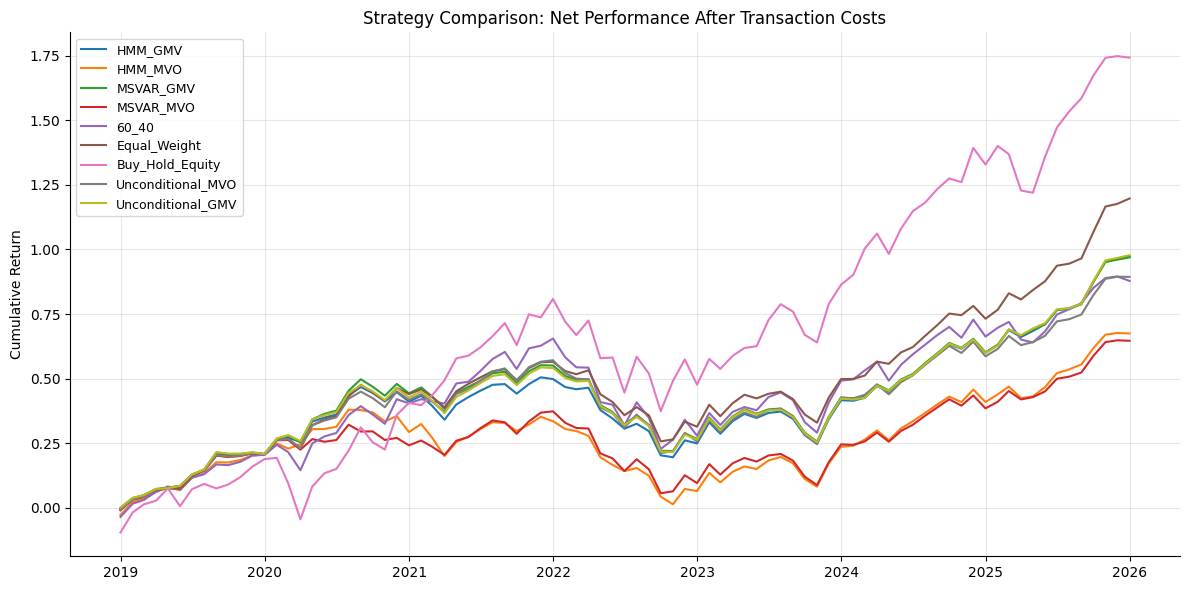

In [10]:
net_return_series = pd.DataFrame({
    k: v['net_return_after_costs'] for k, v in cost_results.items()
})
net_cumulative_returns = (1 + net_return_series).cumprod() - 1
net_cumulative_returns.to_csv(
    OUTPUT_TABLES_DIR / 'net_after_cost_cumulative_returns.csv'
)

fig, ax = plt.subplots(figsize=(12, 6))
for col in net_cumulative_returns.columns:
    ax.plot(net_cumulative_returns.index, net_cumulative_returns[col], label=col)
ax.set_title('Strategy Comparison: Net Performance After Transaction Costs')
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'net_cumulative_returns.png', dpi=300,
            bbox_inches='tight')
plt.show()


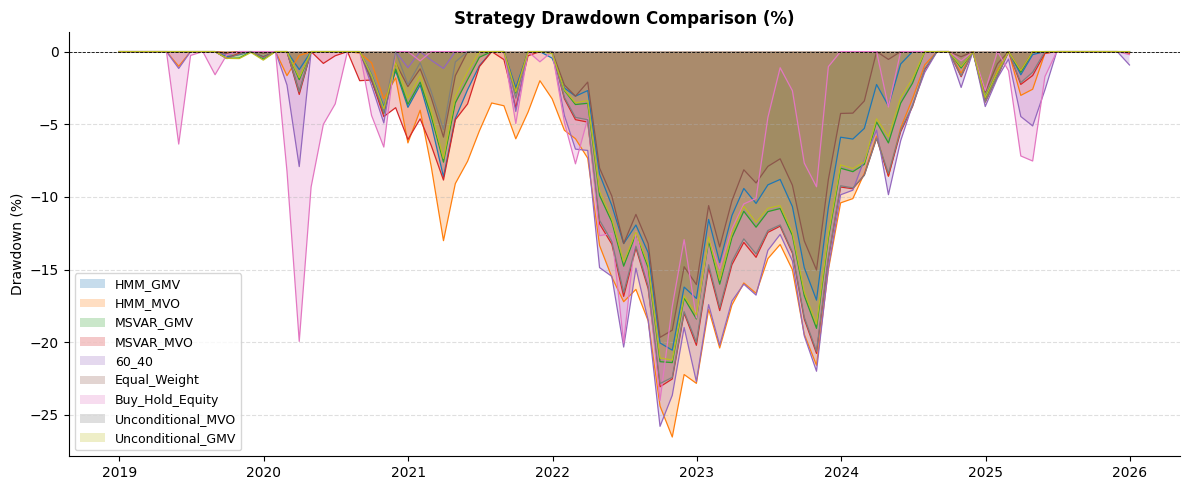

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
for col in net_return_series.columns:
    wealth   = (1 + net_return_series[col]).cumprod()
    roll_max = wealth.expanding().max()
    drawdown = (wealth / roll_max - 1) * 100
    ax.fill_between(wealth.index, drawdown, 0, alpha=0.25, label=col)
    ax.plot(wealth.index, drawdown, lw=0.9)
ax.axhline(0, color='black', lw=0.6, ls='--')
ax.set_title('Strategy Drawdown Comparison (%)', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'drawdown_comparison.png', dpi=300,
            bbox_inches='tight')
plt.show()


In [12]:
ranking_metrics = [
    'Annualized Return',
    'Annualized Volatility',
    'Sharpe Ratio',
    'Sortino Ratio',
    'Max Drawdown',
    'VaR 95% (monthly)',
    'CVaR 95% (monthly)',
    'Information Ratio vs 60/40',
]
available = [m for m in ranking_metrics if m in net_strategy_comparison.index]
strategy_ranking = net_strategy_comparison.loc[available].T
strategy_ranking = strategy_ranking.sort_values('Sharpe Ratio', ascending=False)
strategy_ranking.to_csv(OUTPUT_TABLES_DIR / 'strategy_ranking.csv')
strategy_ranking


,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,VaR 95% (monthly),CVaR 95% (monthly),Information Ratio vs 60/40
Equal_Weight,0.117553,0.099062,0.906967,1.546820,-0.196676,0.031096,0.048981,0.332219
Buy_Hold_Equity,0.153071,0.172510,0.761859,1.131176,-0.240140,0.084115,0.097824,0.735649
HMM_GMV,0.100648,0.098472,0.755704,1.294144,-0.205501,0.033067,0.050003,0.057439
Unconditional_GMV,0.101089,0.101200,0.742001,1.246968,-0.212318,0.033862,0.050857,0.071564
MSVAR_GMV,0.100412,0.102464,0.728034,1.241019,-0.214067,0.033886,0.051581,0.065904
Unconditional_MVO,0.094360,0.107466,0.647344,1.081609,-0.228493,0.034550,0.055918,-0.029184
60_40,0.093072,0.128135,0.552588,0.884541,-0.257916,0.055336,0.070240,NaN
HMM_MVO,0.075541,0.105082,0.493534,0.824904,-0.265265,0.044517,0.058029,-0.275026
MSVAR_MVO,0.072965,0.105032,0.470792,0.762592,-0.230694,0.034739,0.056647,-0.384342


## Implementation cost summary

In [13]:
implementation_cost_summary = pd.DataFrame({
    strategy_name: pd.Series({
        'Average Trade Notional':          result['trade_notional'].mean(),
        'Average One-Way Turnover':        result['one_way_turnover'].mean(),
        'Average Monthly Transaction Cost': result['transaction_cost'].mean(),
    })
    for strategy_name, result in cost_results.items()
})
implementation_cost_summary.to_csv(
    OUTPUT_TABLES_DIR / 'implementation_cost_summary.csv'
)
implementation_cost_summary


,HMM_GMV,HMM_MVO,MSVAR_GMV,MSVAR_MVO,60_40,Equal_Weight,Buy_Hold_Equity,Unconditional_MVO,Unconditional_GMV
Average Trade Notional,0.027191,0.038837,0.045155,0.129977,0.021464,0.024387,0.0,0.023953,0.023759
Average One-Way Turnover,0.013595,0.019419,0.022577,0.064989,0.010732,0.012193,0.0,0.011977,0.011880
Average Monthly Transaction Cost,0.000027,0.000039,0.000045,0.000130,0.000021,0.000024,0.0,0.000024,0.000024


## Subperiod robustness analysis

Checks whether the relative performance of all strategies (MSVAR, HMM, and unconditional GMV/MVO benchmarks) is stable across key market environments in the test window.


In [14]:
common_start = net_return_series.index.min()
common_end   = net_return_series.index.max()

SUBPERIODS = {
    "Full_Test_Period":               (common_start,                    common_end),
    "COVID_2020":                     (pd.Timestamp("2020-03-31"),      pd.Timestamp("2020-12-31")),
    "Inflation_Rate_Rise_2021_2022":  (pd.Timestamp("2021-01-31"),      pd.Timestamp("2022-12-31")),
    "Post_2022_Normalization":        (pd.Timestamp("2023-01-31"),      common_end),
}

subperiod_blocks = []
for period_name, (start, end) in SUBPERIODS.items():
    mask = (net_return_series.index >= start) & (net_return_series.index <= end)
    period_rets = net_return_series.loc[mask]
    if period_rets.empty:
        continue
    # Time-varying rf: use the average FEDFUNDS rate for this specific subperiod
    # rather than the global average over the full test period.
    # This ensures e.g. COVID subperiod Sharpe uses ~0% rf, not 2.66%.
    period_rf = float(
        rf_series.reindex(period_rets.index, method='ffill').fillna(0).mean()
    )
    bench = period_rets['60_40']
    for strat in period_rets.columns:
        s = summarize_performance(
            period_rets[strat],
            benchmark_returns=None if strat == '60_40' else bench,
            risk_free_rate=period_rf,   # subperiod-specific rf
        )
        subperiod_blocks.append({'Subperiod': period_name, 'Strategy': strat,
                                  **s.to_dict()})

subperiod_df = pd.DataFrame(subperiod_blocks).set_index(['Subperiod', 'Strategy'])
subperiod_df.to_csv(OUTPUT_TABLES_DIR / 'subperiod_performance.csv')
subperiod_df[['Annualized Return', 'Sharpe Ratio', 'Max Drawdown']]


Annualized Return  \
Subperiod                     Strategy                               
Full_Test_Period              HMM_GMV                     0.100648   
                              HMM_MVO                     0.075541   
                              MSVAR_GMV                   0.100412   
                              MSVAR_MVO                   0.072965   
                              60_40                       0.093072   
                              Equal_Weight                0.117553   
                              Buy_Hold_Equity             0.153071   
                              Unconditional_MVO           0.094360   
                              Unconditional_GMV           0.101089   
COVID_2020                    HMM_GMV                     0.133864   
                              HMM_MVO                     0.063084   
                              MSVAR_GMV                   0.155477   
                              MSVAR_MVO                  -0.019603   
                              60_40                       0.189232   
                              Equal_Weight                0.166910   
                              Buy_Hold_Equity             0.349695   
                              Unconditional_MVO           0.146312   
                              Unconditional_GMV           0.138100   
Inflation_Rate_Rise_2021_2022 HMM_GMV                    -0.059034   
                              HMM_MVO                    -0.092576   
                              MSVAR_GMV                  -0.063259   
                              MSVAR_MVO                  -0.060593   
                              60_40                      -0.045653   
                              Equal_Weight               -0.044793   
                              Buy_Hold_Equity             0.024736   
                              Unconditional_MVO          -0.058546   
                              Unconditional_GMV          -0.059147   
Post_2022_Normalization       HMM_GMV                     0.164307   
                              HMM_MVO                     0.162914   
                              MSVAR_GMV                   0.158512   
                              MSVAR_MVO                   0.145356   
                              60_40                       0.136549   
                              Equal_Weight                0.186857   
                              Buy_Hold_Equity             0.229128   
                              Unconditional_MVO           0.146411   
                              Unconditional_GMV           0.161040   

                                                 Sharpe Ratio  Max Drawdown  
Subperiod                     Strategy                                       
Full_Test_Period              HMM_GMV                0.755704     -0.205501  
                              HMM_MVO                0.493534     -0.265265  
                              MSVAR_GMV              0.728034     -0.214067  
                              MSVAR_MVO              0.470792     -0.230694  
                              60_40                  0.552588     -0.257916  
                              Equal_Weight           0.906967     -0.196676  
                              Buy_Hold_Equity        0.761859     -0.240140  
                              Unconditional_MVO      0.647344     -0.228493  
                              Unconditional_GMV      0.742001     -0.212318  
COVID_2020                    HMM_GMV                1.211875     -0.038364  
                              HMM_MVO                0.640012     -0.062842  
                              MSVAR_GMV              1.264185     -0.042524  
                              MSVAR_MVO             -0.199294     -0.060525  
                              60_40                  1.141369     -0.049104  
                              Equal_Weight           1.324000     -0.041529  
                              Buy_Hold_Equity        1.254228 

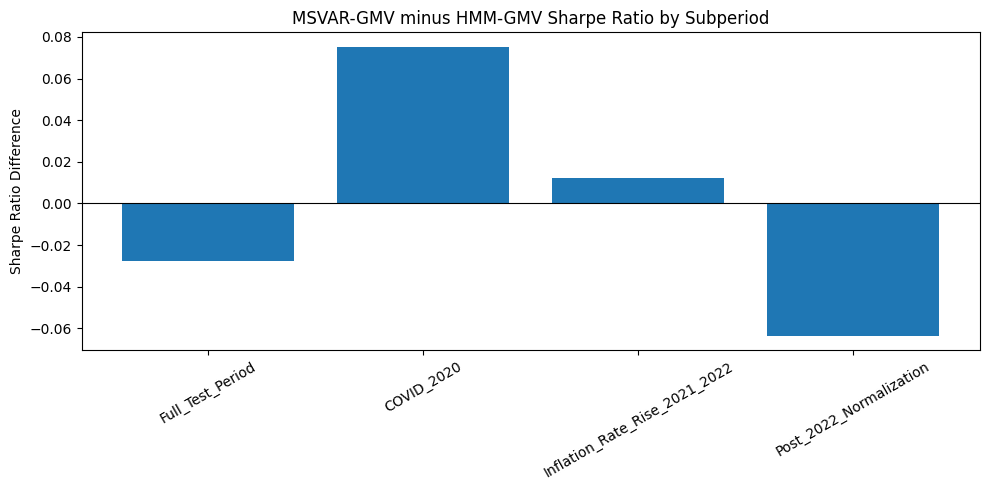

,HMM_GMV Sharpe,MSVAR_GMV Sharpe,MSVAR - HMM Sharpe,HMM_GMV Ann. Return,MSVAR_GMV Ann. Return
Subperiod,,,,,
Full_Test_Period,0.755704,0.728034,-0.027670,0.100648,0.100412
COVID_2020,0.976430,1.051679,0.075249,0.133864,0.155477
Inflation_Rate_Rise_2021_2022,-0.786830,-0.774650,0.012180,-0.059034,-0.063259
Post_2022_Normalization,1.359770,1.296302,-0.063468,0.164307,0.158512


In [15]:
# Compare best MSVAR vs best HMM strategy (GMV) across subperiods
msvar_hmm_rows = []
for period_name, (start, end) in SUBPERIODS.items():
    mask = (net_return_series.index >= start) & (net_return_series.index <= end)
    period_rets = net_return_series.loc[mask]
    if period_rets.empty: continue
    if 'HMM_GMV' not in period_rets.columns or 'MSVAR_GMV' not in period_rets.columns:
        continue
    bench = period_rets['60_40']
    hmm_s   = summarize_performance(period_rets['HMM_GMV'],   bench, ANNUAL_RISK_FREE_RATE)
    msvar_s = summarize_performance(period_rets['MSVAR_GMV'], bench, ANNUAL_RISK_FREE_RATE)
    msvar_hmm_rows.append({
        'Subperiod':              period_name,
        'HMM_GMV Sharpe':         hmm_s['Sharpe Ratio'],
        'MSVAR_GMV Sharpe':       msvar_s['Sharpe Ratio'],
        'MSVAR - HMM Sharpe':     msvar_s['Sharpe Ratio'] - hmm_s['Sharpe Ratio'],
        'HMM_GMV Ann. Return':    hmm_s['Annualized Return'],
        'MSVAR_GMV Ann. Return':  msvar_s['Annualized Return'],
    })

if not msvar_hmm_rows:
    print('No data for MSVAR vs HMM comparison — skipping cell.')
else:
    msvar_vs_hmm = pd.DataFrame(msvar_hmm_rows).set_index('Subperiod')
    msvar_vs_hmm.to_csv(OUTPUT_TABLES_DIR / 'msvar_vs_hmm_subperiod.csv')

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(msvar_vs_hmm.index, msvar_vs_hmm['MSVAR - HMM Sharpe'])
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title('MSVAR-GMV minus HMM-GMV Sharpe Ratio by Subperiod')
    ax.set_ylabel('Sharpe Ratio Difference')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(OUTPUT_FIGURES_DIR / 'msvar_minus_hmm_sharpe_by_subperiod.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    display(msvar_vs_hmm)


## Appendix A: GMV vs MVO comparison

Compares GMV (min-variance) against MVO (max-Sharpe) across all model and unconditional portfolios: HMM-GMV, HMM-MVO, MSVAR-GMV, MSVAR-MVO, Unconditional-GMV, and Unconditional-MVO.


In [16]:
appendix_strategies = ['HMM_GMV', 'HMM_MVO', 'MSVAR_GMV', 'MSVAR_MVO',
                        'Unconditional_GMV', 'Unconditional_MVO']
available_appendix  = [s for s in appendix_strategies if s in cost_results]

# Define locally so this cell runs correctly regardless of execution order.
metric_order = [
    'Annualized Return',
    'Annualized Volatility',
    'Sharpe Ratio',
    'Sortino Ratio',
    'Max Drawdown',
    'VaR 95% (monthly)',
    'CVaR 95% (monthly)',
    'Information Ratio vs 60/40',
]

appendix_comparison = pd.DataFrame({
    s: summarize_performance(
        cost_results[s]['net_return_after_costs'],
        benchmark_returns=cost_results['60_40']['net_return_after_costs'],
        risk_free_rate=ANNUAL_RISK_FREE_RATE,
    )
    for s in available_appendix
})
available_metrics = [m for m in metric_order if m in appendix_comparison.index]
appendix_comparison.loc[available_metrics].to_csv(
    OUTPUT_TABLES_DIR / 'appendix_gmv_vs_mvo.csv'
)
appendix_comparison.loc[available_metrics]


,HMM_GMV,HMM_MVO,MSVAR_GMV,MSVAR_MVO,Unconditional_GMV,Unconditional_MVO
Annualized Return,0.100648,0.075541,0.100412,0.072965,0.101089,0.094360
Annualized Volatility,0.098472,0.105082,0.102464,0.105032,0.101200,0.107466
Sharpe Ratio,0.755704,0.493534,0.728034,0.470792,0.742001,0.647344
Sortino Ratio,1.294144,0.824904,1.241019,0.762592,1.246968,1.081609
Max Drawdown,-0.205501,-0.265265,-0.214067,-0.230694,-0.212318,-0.228493
VaR 95% (monthly),0.033067,0.044517,0.033886,0.034739,0.033862,0.034550
CVaR 95% (monthly),0.050003,0.058029,0.051581,0.056647,0.050857,0.055918
Information Ratio vs 60/40,0.057439,-0.275026,0.065904,-0.384342,0.071564,-0.029184
